# Images and Calibration

> image_transport and the compressed transports, cv_bridge, what CameraInfo actually contains, and the pinhole projection and rectification maths worked through with numpy and OpenCV.

- skip_showdoc: true


## image_transport

Publishing `sensor_msgs/Image` directly sends raw pixels. At 1280x720 RGB8 and 30 Hz that is
**83 MB/s** on one topic, which saturates WiFi, fills a disk in minutes and is usually
unnecessary.

`image_transport` wraps a publisher so that one `publish()` offers several encodings, each on its
own topic, and a subscriber picks one:

```
/camera/image_raw                       sensor_msgs/Image            raw
/camera/image_raw/compressed            sensor_msgs/CompressedImage  JPEG or PNG
/camera/image_raw/theora                theora_image_transport       video codec
/camera/image_raw/compressedDepth       compressed 16-bit depth
```

```cpp
#include <image_transport/image_transport.hpp>
image_transport::ImageTransport it(node);
auto pub = it.advertise("camera/image_raw", 1);     // all transports at once
pub.publish(msg);
```

The plugins are **lazy**: nothing is encoded until somebody subscribes to that transport, so
offering them costs nothing.

Three practical points:

- **Subscribe to the base topic name**, not the suffixed one. `it.subscribe("camera/image_raw",
  ...)` plus a parameter `image_transport:=compressed` picks the transport. Subscribing to
  `/camera/image_raw/compressed` as a plain `CompressedImage` works but loses the abstraction.
- **`image_transport` is C++ only.** There is no rclpy equivalent, so a Python node subscribes
  to `CompressedImage` directly and decodes with `cv2.imdecode`.
- **Depth images must not be JPEG compressed.** Lossy compression of a 16-bit depth map produces
  plausible, wrong geometry. `compressedDepth` exists for this; plain `compressed` on a depth
  topic is a bug.

```bash
ros2 run image_transport republish raw in:=/camera/image_raw compressed out:=/camera/image_c
ros2 topic bw /camera/image_raw /camera/image_raw/compressed
```

---


## cv_bridge

`cv_bridge` converts between `sensor_msgs/Image` and an OpenCV array.

```python
from cv_bridge import CvBridge
bridge = CvBridge()

def on_image(self, msg):
    cv = bridge.imgmsg_to_cv2(msg, desired_encoding="bgr8")   # always name the encoding
    gray = cv2.cvtColor(cv, cv2.COLOR_BGR2GRAY)
    out = bridge.cv2_to_imgmsg(gray, encoding="mono8")
    out.header = msg.header            # carry the stamp and frame_id forward
    self.pub.publish(out)
```

`out.header = msg.header` is the line people forget. A derived image with a fresh stamp and no
`frame_id` cannot be transformed or synchronised downstream; see
[../03_Spatial_and_Temporal/02_Conventions_and_Time.ipynb](../03_Spatial_and_Temporal/02_Conventions_and_Time.ipynb).

Encodings that matter, because mixing them up produces images that look almost right:

| Encoding | Layout | Note |
|----------|--------|------|
| `bgr8` | 3x8-bit, blue first | OpenCV's native order |
| `rgb8` | 3x8-bit, red first | what most other tools expect |
| `mono8` | 1x8-bit | greyscale |
| `16UC1` | 1x16-bit unsigned | depth in **millimetres** |
| `32FC1` | 1x32-bit float | depth in **metres** |
| `bayer_rggb8` | raw sensor mosaic | needs debayering first |

**`desired_encoding="passthrough"` is a trap.** It hands over whatever the camera sent, so code
tested against a `bgr8` camera silently receives `bayer_rggb8` or `mono8` from a different one
and produces garbage rather than an error. Naming the encoding makes `cv_bridge` convert or
raise.

**Depth units are the other recurring bug**: `16UC1` is millimetres and `32FC1` is metres, so
reading a depth image without checking the encoding gives answers wrong by 1000.

---


## CameraInfo

`sensor_msgs/CameraInfo` travels alongside the image, on a sibling topic
(`/camera/camera_info`), and holds everything needed to turn pixels into directions.

| Field | Is |
|-------|----|
| `k` (3x3, row-major) | intrinsics: `fx 0 cx / 0 fy cy / 0 0 1`, for the **raw** image |
| `d` | distortion coefficients, `k1 k2 t1 t2 k3` for `plumb_bob` |
| `distortion_model` | usually `plumb_bob`, sometimes `equidistant` for fisheye |
| `r` (3x3) | rectification rotation; identity for a monocular camera |
| `p` (3x4) | projection matrix for the **rectified** image; `tx` non-zero on the right camera of a stereo pair |
| `width`, `height` | the resolution these numbers apply to |
| `binning_*`, `roi` | set if the driver is cropping or binning |

Two rules that follow from the raw-versus-rectified split:

- **Use `k` with a raw image and `p` with a rectified one.** Mixing them gives a projection that
  is wrong by the distortion correction, which looks like a small calibration error and is not.
- **Intrinsics are resolution specific.** Changing the camera mode from 1280x720 to 640x480
  invalidates `k` unless the driver rescales it. Check `width`/`height` against the image.

Calibrating:

```bash
ros2 run camera_calibration cameracalibrator \
  --size 8x6 --square 0.025 image:=/camera/image_raw camera:=/camera
```

The result is a YAML file the driver loads and republishes. A camera publishing an all-zero `k`
is uncalibrated, and every geometric consumer downstream silently produces nonsense.

---


## Projection, Worked Through

The pinhole model is four numbers and one division. Everything else in camera geometry builds on
it, so it is worth running once.

---


In [ ]:
import numpy as np
import cv2

# a plausible 640x480 webcam calibration
W, H = 640, 480
K = np.array([[525.0,   0.0, 319.5],
              [  0.0, 525.0, 239.5],
              [  0.0,   0.0,   1.0]])
D = np.array([-0.28, 0.09, 0.0005, -0.0002, 0.0])      # plumb_bob: k1 k2 t1 t2 k3
print("fx, fy =", K[0, 0], K[1, 1], "   cx, cy =", K[0, 2], K[1, 2])

def project(K, pts_cam):
    "3D points in the OPTICAL frame (z forward) -> pixel coordinates"
    uvw = K @ pts_cam.T
    return (uvw[:2] / uvw[2]).T

def unproject(K, uv, depth):
    "pixels + known depth -> 3D points in the optical frame"
    h = np.hstack([uv, np.ones((len(uv), 1))])
    return (np.linalg.inv(K) @ h.T).T * depth[:, None]

pts = np.array([[0.0, 0.0, 2.0],      # straight down the optical axis
                [0.3, 0.2, 2.0],      # right and down a bit
                [-0.5, 0.1, 4.0]])    # left, further away
uv = project(K, pts)
for p, q in zip(pts, uv):
    print(f"  {p} m  ->  pixel ({q[0]:7.2f}, {q[1]:7.2f})")

# the optical axis lands exactly on the principal point
assert np.allclose(uv[0], [K[0, 2], K[1, 2]])
# and unprojecting at the true depth recovers the point
assert np.allclose(unproject(K, uv, pts[:, 2]), pts, atol=1e-10)
print("\nprojection round-trip exact to 1e-10")


fx, fy = 525.0 525.0    cx, cy = 319.5 239.5
  [0. 0. 2.] m  ->  pixel ( 319.50,  239.50)
  [0.3 0.2 2. ] m  ->  pixel ( 398.25,  292.00)
  [-0.5  0.1  4. ] m  ->  pixel ( 253.88,  252.62)

projection round-trip exact to 1e-10


In [ ]:
# The optical frame is NOT the body frame. REP-103 body axes are x forward, y left, z up;
# the optical frame used by every image is z forward, x right, y down. A camera_link to
# camera_optical_frame transform exists precisely to hold this rotation.
BODY_TO_OPTICAL = np.array([[0, -1,  0],
                            [0,  0, -1],
                            [1,  0,  0]], dtype=float)
assert np.isclose(np.linalg.det(BODY_TO_OPTICAL), 1.0)   # a proper rotation

p_body = np.array([2.0, 0.0, 0.0])          # 2 m straight ahead of the robot
p_opt = BODY_TO_OPTICAL @ p_body
print("body (x fwd, y left, z up):", p_body)
print("optical (x right, y down, z fwd):", p_opt)
assert np.allclose(p_opt, [0.0, 0.0, 2.0])
assert np.allclose(BODY_TO_OPTICAL.T @ p_opt, p_body)

# projecting a body-frame point means rotating it first; skipping this is the
# classic "my detections are 90 degrees off" bug
print("\npixel for a point 2 m ahead:", project(K, p_opt[None, :])[0].round(2))


body (x fwd, y left, z up): [2. 0. 0.]
optical (x right, y down, z fwd): [0. 0. 2.]

pixel for a point 2 m ahead: [319.5 239.5]


In [ ]:
# Distortion, and undoing it. projectPoints applies the plumb_bob model;
# undistortPoints inverts it.
rvec = tvec = np.zeros(3)
uv_distorted, _ = cv2.projectPoints(pts, rvec, tvec, K, D)
uv_distorted = uv_distorted.reshape(-1, 2)
uv_recovered = cv2.undistortPoints(uv_distorted.reshape(-1, 1, 2), K, D, P=K).reshape(-1, 2)

print(f"{'ideal':>18}  {'distorted':>18}  {'recovered':>18}   shift (px)")
for ideal, dist, rec in zip(uv, uv_distorted, uv_recovered):
    shift = np.linalg.norm(dist - ideal)
    print(f"  ({ideal[0]:7.2f},{ideal[1]:7.2f})   ({dist[0]:7.2f},{dist[1]:7.2f})   "
          f"({rec[0]:7.2f},{rec[1]:7.2f})     {shift:5.2f}")

assert np.allclose(uv_recovered, uv, atol=1e-3)
print(f"\nround-trip error: {np.abs(uv_recovered - uv).max():.2e} px")


             ideal           distorted           recovered   shift (px)
  ( 319.50, 239.50)   ( 319.50, 239.50)   ( 319.50, 239.50)      0.00
  ( 398.25, 292.00)   ( 397.54, 291.54)   ( 398.25, 292.00)      0.85
  ( 253.88, 252.62)   ( 254.17, 252.57)   ( 253.88, 252.62)      0.30

round-trip error: 1.28e-09 px


In [ ]:
# Rectification as a pixel map. This is what image_proc::RectifyNode does per frame:
# build the map once, then cv2.remap every image.
P, roi = cv2.getOptimalNewCameraMatrix(K, D, (W, H), alpha=0)
map1, map2 = cv2.initUndistortRectifyMap(K, D, None, P, (W, H), cv2.CV_32FC1)
print("P (intrinsics for the RECTIFIED image):\n", P.round(2))
print("valid roi:", roi, "  map shape:", map1.shape, map1.dtype)

# how far each pixel moves: small in the centre, large at the corners
vv, uu = np.mgrid[0:H, 0:W].astype(np.float32)
displacement = np.sqrt((map1 - uu) ** 2 + (map2 - vv) ** 2)
print(f"\ndisplacement: centre {displacement[H // 2, W // 2]:.2f} px, "
      f"mean {displacement.mean():.1f} px, max {displacement.max():.1f} px")
assert displacement.max() > 5.0
assert displacement[H // 2, W // 2] < displacement.max()   # distortion grows outward
print("note fx in P differs from fx in K:", round(P[0, 0], 1), "vs", K[0, 0],
      "- which is why a consumer must use the right one")


P (intrinsics for the RECTIFIED image):
 [[466.45   0.   319.31]
 [  0.   492.93 239.71]
 [  0.     0.     1.  ]]
valid roi: (0, 0, 639, 479)   map shape: (480, 640) float32

displacement: centre 0.33 px, mean 9.0 px, max 28.0 px
note fx in P differs from fx in K: 466.4 vs 525.0 - which is why a consumer must use the right one


left: straight-line input      right: after the rectification map


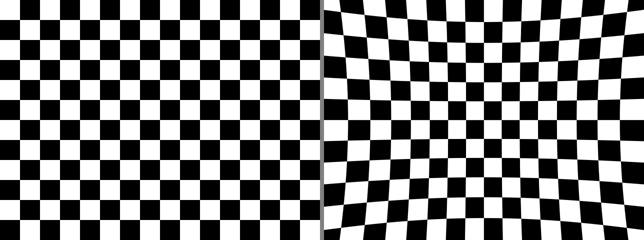

In [ ]:
# A synthetic checkerboard pushed through the same map, to see the warp rather than
# read about it. Straight lines in, curved lines out.
board = np.zeros((H, W), np.uint8)
square = 40
for r in range(H // square):
    for c in range(W // square):
        if (r + c) % 2 == 0:
            board[r * square:(r + 1) * square, c * square:(c + 1) * square] = 255

warped = cv2.remap(board, map1, map2, cv2.INTER_LINEAR)
assert warped.shape == board.shape and warped.dtype == np.uint8

from PIL import Image
from IPython.display import display
side_by_side = np.hstack([board, np.full((H, 8), 128, np.uint8), warped])
print("left: straight-line input      right: after the rectification map")
display(Image.fromarray(side_by_side).resize((side_by_side.shape[1] // 2, H // 2)))


## What to Check When Geometry Is Wrong

Projection bugs do not announce themselves; they produce detections that are plausibly placed
and consistently wrong. The checks, cheapest first:

```bash
ros2 topic echo /camera/camera_info --once         # is k all zeros?
ros2 topic hz /camera/camera_info                 # is it published at all
ros2 run tf2_ros tf2_echo base_link camera_optical_frame
ros2 run image_view image_view image:=/camera/image_rect
```

| Symptom | Likely cause |
|---------|--------------|
| `k` all zeros | camera never calibrated |
| everything offset by a constant | `k` used on a rectified image, or `p` on a raw one |
| error grows toward the frame edge | distortion not corrected at all |
| detections rotated 90 degrees or mirrored | optical frame treated as the body frame |
| scale wrong by 2 | camera resolution changed without rescaling `k` |
| depth wrong by 1000 | `16UC1` millimetres read as `32FC1` metres |
| detections lag the robot | image restamped instead of carrying the original header |

The `camera_optical_frame` check is worth making a habit: a URDF that omits the optical frame and
mounts the camera directly as `camera_link` is a common shortcut, and every projection through it
is rotated.

Model inference on these images is [02_Inference_Node_Integration.ipynb](02_Inference_Node_Integration.ipynb).

---
